# The Central Limit Theorem

The *Central Limit Theorem* states that if we draw a simple random sample of size $n$ from any population with mean $\mu$ and standard deviation $\sigma$, if $n$ is large, the distribution of the sample means is approximately normal of the form

$$N(\mu, \frac{\sigma}{n})$$

This activity is meant to offer an example of the central limit theorem in action and the effect of using different sample sizes in forming the distribution of sample means. 

### Baseball Salaries

![](images/baseballs.png)


The dataset below represents Major League Baseball player salaries from the year 2020 and was gathered from USA Today's databases. Below, the dataset is loaded, and we examine the features and datatypes. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#read in the data
baseball_salaries = pd.read_csv('baseball.csv', index_col=0)

In [3]:
#Examine the .info()
baseball_salaries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797 entries, 1 to 797
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   team         797 non-null    object
 1   leagueID     797 non-null    object
 2   player       797 non-null    object
 3   salary       797 non-null    int64 
 4   position     797 non-null    object
 5   gamesplayed  797 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 43.6+ KB


In [4]:
#First few rows
baseball_salaries.head()

,team,leagueID,player,salary,position,gamesplayed
1,ANA,AL,anderga0,6200000,CF,112
2,ANA,AL,colonba0,11000000,P,3
3,ANA,AL,davanje0,375000,CF,108
4,ANA,AL,donnebr0,375000,P,5
5,ANA,AL,eckstda0,2150000,SS,142


### Task

Our goal is to take samples from the salary data and build a distribution of these sample means.  To begin, draw a histogram of the salaries.  Note the skew and lack of normality in this distribution.    

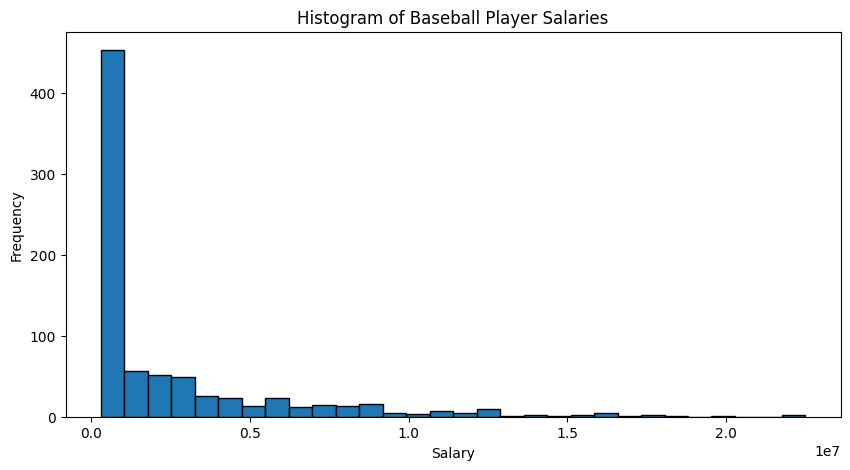

Skewness of salary distribution: 2.364699326738175


In [5]:
# Histogram of the salaries
plt.figure(figsize=(10,5))
plt.hist(baseball_salaries["salary"], bins=30, edgecolor="black")
plt.title("Histogram of Baseball Player Salaries")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# (Optional) quick check for skewness
print("Skewness of salary distribution:", baseball_salaries["salary"].skew())

### Taking Samples

Pandas DataFrame has built-in methods for taking random samples with replacement.  The `.sample()` method is demonstrated below.

In [6]:
baseball_salaries['salary'].sample(4)

759    1800000
683     303000
788    2000000
306    3000000
Name: salary, dtype: int64

### Sample Means

Now, use this method to repeatedly take samples and build a list of sample means.  As a starting place let us take 1000 samples of size 5 and draw the histogram of the sample means.  What is the mean and standard deviation? 

In [7]:
#empty list for sample means
sample_means = []
for i in range(1000):
    samp = baseball_salaries["salary"].sample(n=5, replace=True)  # sample with replacement
    sample_means.append(samp.mean())

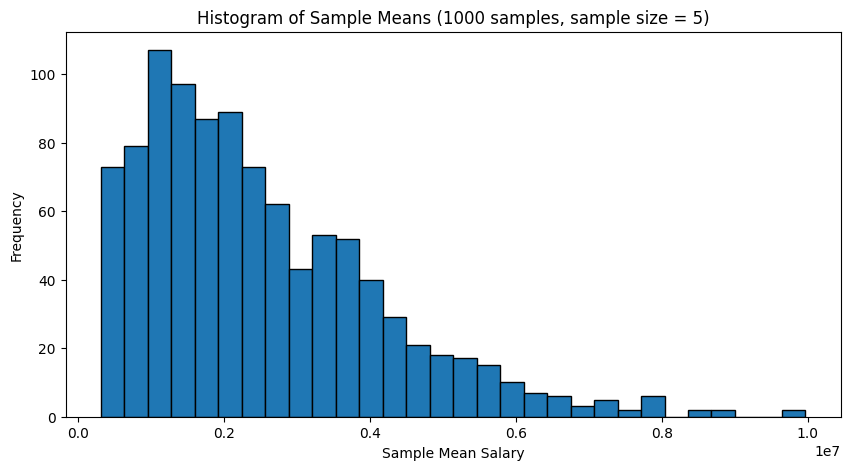

Mean of sample means: 2504415.1226
Standard deviation of sample means: 1640579.479358847


In [8]:
# Convert to numpy array (optional, easier for calculations)
sample_means = np.array(sample_means)

# Histogram of sample means
plt.figure(figsize=(10,5))
plt.hist(sample_means, bins=30, edgecolor="black")
plt.title("Histogram of Sample Means (1000 samples, sample size = 5)")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.show()

# Mean and standard deviation of the sample means distribution
print("Mean of sample means:", sample_means.mean())
print("Standard deviation of sample means:", sample_means.std())

Repeat the above exercise with samples of size:

- 10
- 25
- 50
- 100

Your discussion post should explain how the distribution of these sample means changes as the sample size changes, and how the mean and standard deviation of the distributions change.

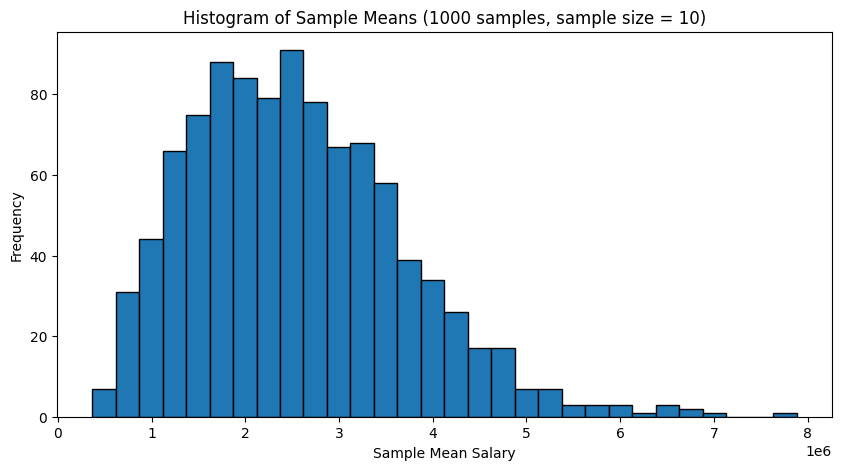

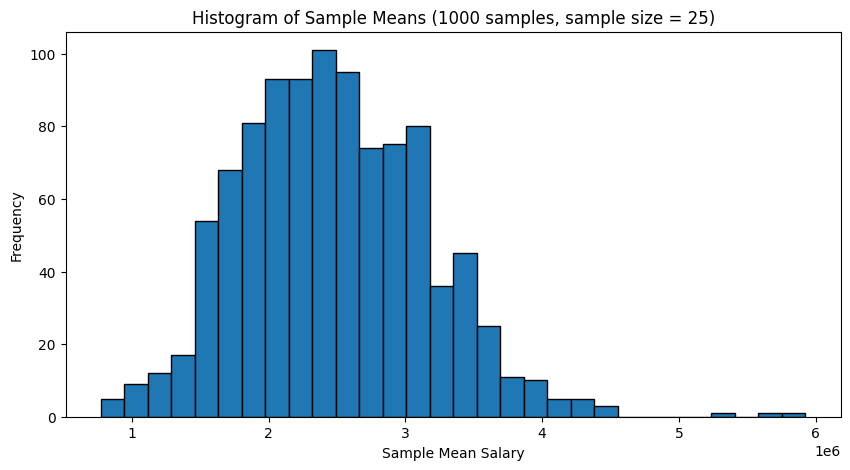

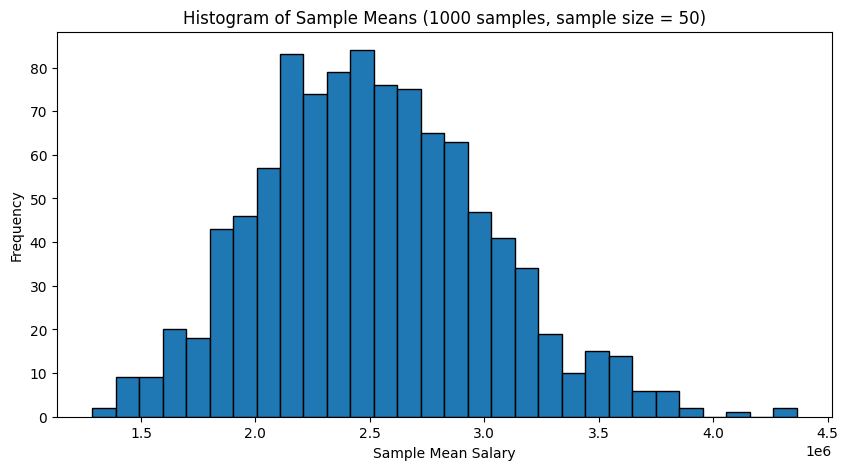

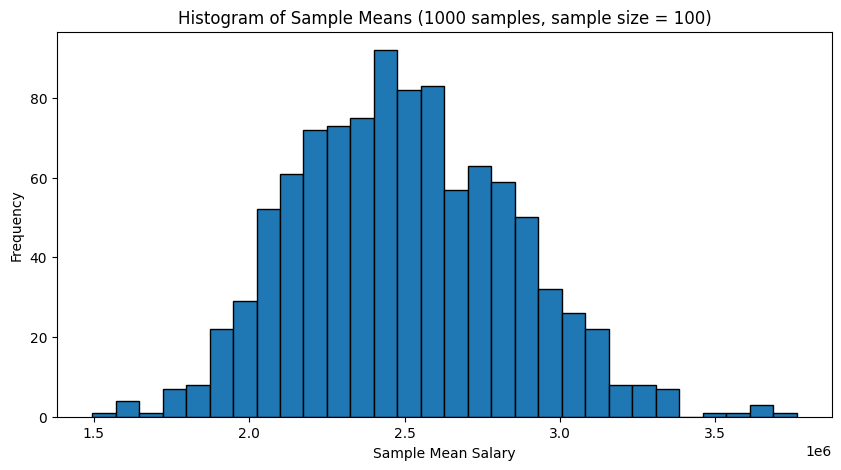

Summary of Sample Means Distributions:
n=10: mean=2555991.46, std=1141563.11
n=25: mean=2476561.26, std=684524.85
n=50: mean=2518369.45, std=495338.16
n=100: mean=2498612.61, std=346211.75


In [9]:
import numpy as np
import matplotlib.pyplot as plt

sample_sizes = [10, 25, 50, 100]
num_samples = 1000

results = {}

for n in sample_sizes:
    sample_means = []

    for i in range(num_samples):
        samp = baseball_salaries["salary"].sample(n=n, replace=True)
        sample_means.append(samp.mean())

    sample_means = np.array(sample_means)
    results[n] = {
        "mean": sample_means.mean(),
        "std": sample_means.std()
    }

    # Plot histogram
    plt.figure(figsize=(10,5))
    plt.hist(sample_means, bins=30, edgecolor="black")
    plt.title(f"Histogram of Sample Means (1000 samples, sample size = {n})")
    plt.xlabel("Sample Mean Salary")
    plt.ylabel("Frequency")
    plt.show()

# Print summary table
print("Summary of Sample Means Distributions:")
for n in sample_sizes:
    print(f"n={n}: mean={results[n]['mean']:.2f}, std={results[n]['std']:.2f}")
